# Etap 4 – Eksploracyjna analiza danych (EDA)

Analiza kohorty TCGA-GBM + TCGA-LGG (n=1047) na podstawie danych złączonych
z trzech tabel bazy `db/tcga_glioma.db` (patients, biomarkers, survival).
Cel: opisać kohortę liczbowo i wizualnie przed przejściem do analizy przeżycia (Etap 5).

## 1. Wczytanie danych

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DB_PATH = Path('../db/tcga_glioma.db')
conn = sqlite3.connect(DB_PATH)

print("Połączono z bazą")

Połączono z bazą


In [2]:
query = """
SELECT p.patient_id, p.study, p.histology, p.grade, p.age_at_diagnosis,
       p.gender, p.kps, p.mutation_count,
       b.idh_status, b.mgmt_status, b.codel_1p19q, b.idh_codel_subtype,
       b.tert_promoter_status, b.atrx_status,
       s.os_months, s.os_event
FROM patients p
JOIN biomarkers b ON p.patient_id = b.patient_id
JOIN survival s ON p.patient_id = s.patient_id;
"""
df = pd.read_sql_query(query, conn)

print(df.shape)
df.head()

(1047, 16)


,patient_id,study,histology,grade,age_at_diagnosis,gender,kps,mutation_count,idh_status,mgmt_status,codel_1p19q,idh_codel_subtype,tert_promoter_status,atrx_status,os_months,os_event
0,TCGA-CS-4938,LGG,astrocytoma,G2,31.0,female,90.0,15.0,Mutant,Unmethylated,non-codel,IDHmut-non-codel,WT,Mutant,4.698251,0.0
1,TCGA-CS-4941,LGG,astrocytoma,G3,67.0,male,90.0,50.0,WT,Methylated,non-codel,IDHwt,Mutant,WT,7.688047,1.0
2,TCGA-CS-4942,LGG,astrocytoma,G3,44.0,female,90.0,24.0,Mutant,Unmethylated,non-codel,IDHmut-non-codel,WT,Mutant,43.861292,1.0
3,TCGA-CS-4943,LGG,astrocytoma,G3,37.0,male,50.0,30.0,Mutant,Methylated,non-codel,IDHmut-non-codel,WT,Mutant,18.135905,0.0
4,TCGA-CS-4944,LGG,astrocytoma,G2,50.0,male,90.0,20.0,Mutant,Methylated,non-codel,IDHmut-non-codel,Mutant,WT,10.612133,0.0


In [3]:
# Zmienne liczbowe: średnia, odchylenie, n - cała kohorta i per study
zmienne_liczbowe = ['age_at_diagnosis', 'kps', 'mutation_count', 'os_months']
df[zmienne_liczbowe].describe()

,age_at_diagnosis,kps,mutation_count,os_months
count,1047.000000,697.000000,754.000000,1047.000000
mean,51.423114,81.305595,54.201592,19.131844
std,15.775964,14.548369,445.809777,24.217541
min,10.000000,20.000000,0.000000,-0.032855
25%,39.000000,80.000000,21.000000,5.388204
50%,52.000000,80.000000,35.000000,11.729199
75%,63.000000,90.000000,51.750000,21.142128
max,89.000000,100.000000,12255.000000,211.027023


In [6]:
df[df['os_months'] < 0]

,patient_id,study,histology,grade,age_at_diagnosis,gender,kps,mutation_count,idh_status,mgmt_status,codel_1p19q,idh_codel_subtype,tert_promoter_status,atrx_status,os_months,os_event
357,TCGA-QH-A6CU,LGG,oligodendroglioma,G3,52.0,female,90.0,12.0,Mutant,Methylated,codel,IDHmut-codel,NaN,WT,-0.032855,0.0
359,TCGA-QH-A6CW,LGG,oligoastrocytoma,G3,43.0,male,90.0,30.0,Mutant,Methylated,non-codel,IDHmut-non-codel,NaN,Mutant,-0.032855,0.0
360,TCGA-QH-A6CX,LGG,astrocytoma,G2,66.0,male,90.0,30.0,WT,Unmethylated,non-codel,IDHwt,NaN,WT,-0.032855,0.0


In [7]:
# Wykluczenie pacjentów z błędnym (ujemnym) os_months
df = df[df['os_months'] >= 0].reset_index(drop=True)
print(df.shape)

(1044, 16)


Decyzja (Etap 4): 3 pacjentów z ujemnym os_months (wszyscy z source site QH) wykluczono z analizy jako błąd danych źródłowych. Efektywna kohorta: n=1044.

## 2. Charakterystyka kohorty

Kohorta: 1047 pacjentów, 590 GBM (56%) i 457 LGG (44%). Średni wiek diagnozy
51,4 lat (SD 15,8), z wyraźną różnicą między grupami: GBM 57,8 lat (SD 14,4)
vs LGG 43,2 lat (SD 13,5) - zgodnie z epidemiologią (GBM częstszy u starszych
pacjentów). Płeć: 618 mężczyzn (59%), 429 kobiet (41%).

Status IDH: 406 mutant (39%), 520 wildtype (50%), 121 braków (11,6%).
Status MGMT: 560 metylowany (54%), 302 niemetylowany (29%), 185 braków (17,7%).
Kodelecja 1p/19q: 153 obecna (15%), 872 nieobecna (83%), 22 braki (2,1%).

Dodatkowe braki danych: KPS (Karnofsky Performance Status) - 350 braków (33,5%);
liczba mutacji somatycznych - 293 braki (28,1%), rozkład silnie prawoskośny
(mediana 35, średnia 54,2, maksimum 12255 — pojedynczy fenotyp hipermutacyjny,
prawdopodobnie związany z leczeniem temozolomidem w nawrotowym LGG).

In [4]:
# Rozbite na GBM vs LGG
df.groupby('study')[zmienne_liczbowe].agg(['mean', 'std', 'count']).round(1)

age_at_diagnosis               kps             mutation_count         \
                  mean   std count  mean   std count           mean    std   
study                                                                        
GBM               57.8  14.4   590  77.4  14.5   435           51.7   21.0   
LGG               43.2  13.5   457  87.7  12.1   262           55.8  573.9   

            os_months              
      count      mean   std count  
study                              
GBM     299      14.8  16.6   590  
LGG     455      24.7  30.6   457

In [5]:
# Zmienne kategoryczne: liczby i udział % per study
zmienne_kategoryczne = ['gender', 'grade', 'idh_status', 'mgmt_status', 'codel_1p19q', 'os_event']

for col in zmienne_kategoryczne:
    print(f"--- {col} ---")
    tabela = pd.crosstab(df[col], df['study'], margins=True, margins_name='Razem')
    print(tabela)
    print()

--- gender ---
study   GBM  LGG  Razem
gender                 
female  228  201    429
male    362  256    618
Razem   590  457   1047

--- grade ---
study  GBM  LGG  Razem
grade                 
G2       0  216    216
G3       0  241    241
G4     590    0    590
Razem  590  457   1047

--- idh_status ---
study       GBM  LGG  Razem
idh_status                 
Mutant       37  369    406
WT          434   86    520
Razem       471  455    926

--- mgmt_status ---
study         GBM  LGG  Razem
mgmt_status                  
Methylated    183  377    560
Unmethylated  222   80    302
Razem         405  457    862

--- codel_1p19q ---
study        GBM  LGG  Razem
codel_1p19q                 
codel          2  151    153
non-codel    566  306    872
Razem        568  457   1025

--- os_event ---
study     GBM  LGG  Razem
os_event                 
0.0       145  377    522
1.0       444   80    524
Razem     589  457   1046



In [8]:
kolumny = ['idh_status', 'mgmt_status', 'codel_1p19q', 'kps', 'mutation_count', 'os_event']
braki = df[kolumny].isnull().sum()
braki_pct = (braki / len(df) * 100).round(1)

podsumowanie_brakow = pd.DataFrame({'liczba_brakow': braki, 'procent': braki_pct})
podsumowanie_brakow

,liczba_brakow,procent
idh_status,121,11.6
mgmt_status,185,17.7
codel_1p19q,22,2.1
kps,350,33.5
mutation_count,293,28.1
os_event,1,0.1


## 3. Rozkład wieku w momencie diagnozy

Rozkład wieku w całej kohorcie jest lekko dwumodalny - wynika to z połączenia
dwóch różnych populacji: LGG z pikiem ok. 30-35 lat i GBM z pikiem ok. 55-65 lat,
widocznym po rozbiciu wykresu na `study`.

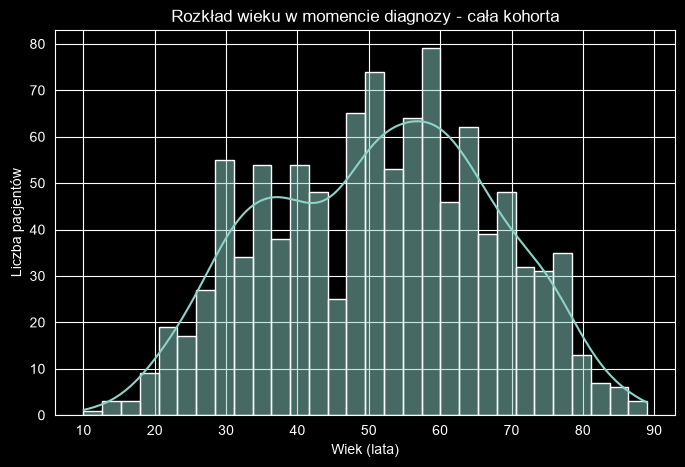

In [9]:
# Histogram wieku diagnozy, cała kohorta
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age_at_diagnosis', bins=30, kde=True)
plt.title('Rozkład wieku w momencie diagnozy - cała kohorta')
plt.xlabel('Wiek (lata)')
plt.ylabel('Liczba pacjentów')
plt.show()

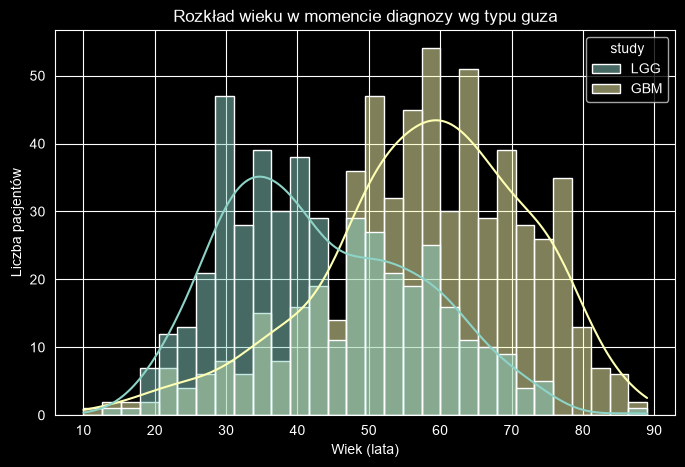

In [10]:
# Rozbite na GBM vs LGG
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age_at_diagnosis', hue='study', bins=30, kde=True, alpha=0.5)
plt.title('Rozkład wieku w momencie diagnozy wg typu guza')
plt.xlabel('Wiek (lata)')
plt.ylabel('Liczba pacjentów')
plt.show()

## 4. Rozkłady biomarkerów wg typu guza

IDH mutant silnie skoncentrowany w LGG (369/455 = 81%) i rzadki w GBM
(37/471 = 8%) - IDH to biomarker mocno różnicujący oba typy guza.
MGMT methylated również częstszy w LGG (377/457 = 82%) niż w GBM
(183/405 = 45%), ale różnica jest mniej wyraźna niż dla IDH.

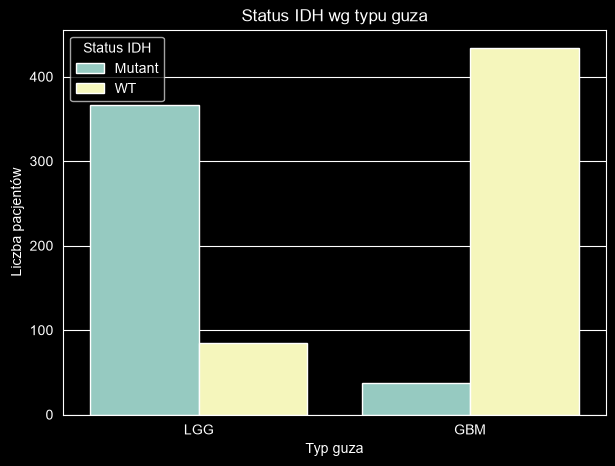

In [11]:
# Rozkład statusu IDH wg typu guza
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='study', hue='idh_status')
plt.title('Status IDH wg typu guza')
plt.xlabel('Typ guza')
plt.ylabel('Liczba pacjentów')
plt.legend(title='Status IDH')
plt.show()

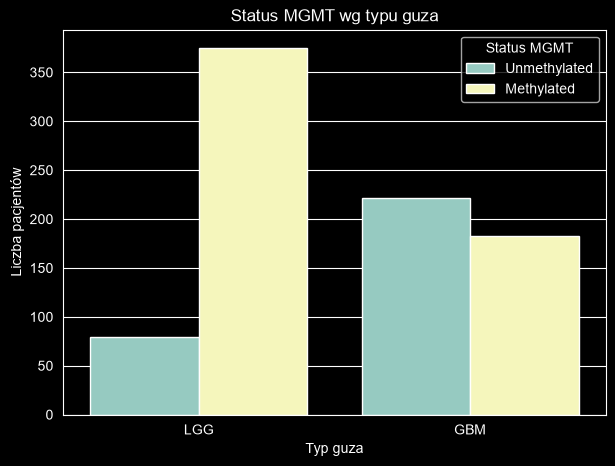

In [12]:
# Rozkład statusu MGMT wg typu guza
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='study', hue='mgmt_status')
plt.title('Status MGMT wg typu guza')
plt.xlabel('Typ guza')
plt.ylabel('Liczba pacjentów')
plt.legend(title='Status MGMT')
plt.show()

## 5. Współwystępowanie IDH i MGMT

Najliczniejsza kombinacja: IDH mutant + MGMT methylated (365 pacjentów) -
typowy profil dla LGG o lepszym rokowaniu. Kombinacja IDH wildtype + MGMT
unmethylated (245 pacjentów) jest typowa dla GBM o najgorszym rokowaniu
i najsłabszej odpowiedzi na temozolomid.

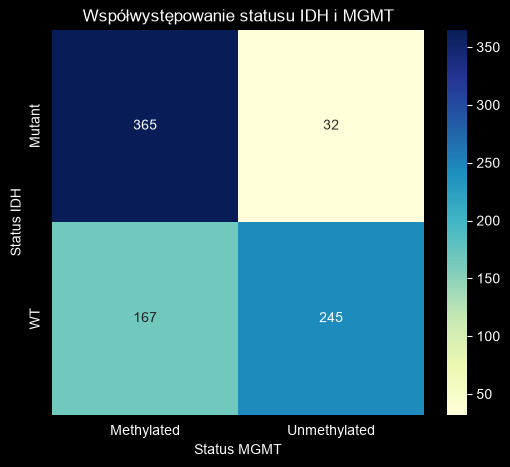

In [13]:
# Tabela krzyżowa IDH x MGMT
tabela_biomarkerow = pd.crosstab(df['idh_status'], df['mgmt_status'])

plt.figure(figsize=(6, 5))
sns.heatmap(tabela_biomarkerow, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Współwystępowanie statusu IDH i MGMT')
plt.xlabel('Status MGMT')
plt.ylabel('Status IDH')
plt.show()

## 6. Podsumowanie i decyzje dot. jakości danych

- **Ujemny `os_months`** u 3 pacjentów (wszyscy z TCGA source site QH) -
  wykluczeni z analizy jako błąd danych źródłowych. Kohorta po wykluczeniu: n=1044.
- **Braki w IDH/MGMT** (11,6% / 17,7%) - bez imputacji; pacjenci z brakiem
  w tych zmiennych będą wykluczani z analiz, które z nich korzystają.
  Efektywna kohorta z kompletnym IDH+MGMT (do modelu Coxa, Etap 5): n=809.
- **Brak danych o leczeniu** - nie pozyskano z TCGA w tym projekcie;
  ograniczenie do uwzględnienia w dyskusji pracy.